In [2]:
"""

Original version: Dr. Sreenivas Bhattiprolu 
Modified: Denis D.

Tasks achieved.

1. Read large images and corresponding masks, divide them into smaller patches.
And write the patches as images to the local drive.  

2. Save only images and masks where masks have some decent amount of labels other than 0. 
Using blank images with label=0 is a waste of time and may bias the model towards 
unlabeled pixels. 

3. Divide the sorted dataset from above into train and validation datasets. 

4. You have to manually move some folders and rename appropriately if you want to use 
ImageDataGenerator from keras. 

## Note: Use VGG Image Annotator to create masks.
# https://www.robots.ox.ac.uk/~vgg/software/via/

"""

import os
import cv2
import numpy as np
import glob
from osgeo import gdal

import numpy as np
from matplotlib import pyplot as plt
from patchify import patchify
import tifffile as tiff
from PIL import Image
#import tensorflow as tf
#from tensorflow import keras
import segmentation_models as sm
#from tensorflow.keras.metrics import MeanIoU
import random
import warnings
from PIL import Image
import imageio

2023-08-18 23:54:11.612564: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-08-18 23:54:11.838585: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/denis/.conda/envs/proba/lib/python3.10/site-packages/cv2/../../../../lib::/usr/local/GAMMA_SOFTWARE-20201216/lib:/usr/local/lib
2023-08-18 23:54:11.838634: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-08-18 23:54:11.871846: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: At

Segmentation Models: using `keras` framework.


In [3]:
def anisodiff(img, niter=20, kappa=100, gamma=0.25, step=(1., 1.), option=1):
        """
        Anisotropic diffusion.
        Usage:
        imgout = anisodiff(im, niter, kappa, gamma, option)
        Arguments:
                img    - input image
                niter  - number of iterations
                kappa  - conduction coefficient 20-100 ?
                gamma  - max value of .25 for stability
                step   - tuple, the distance between adjacent pixels in (y,x)
                option - 1 Perona Malik diffusion equation No 1
                         2 Perona Malik diffusion equation No 2
        Returns:
                imgout   - diffused image.
        kappa controls conduction as a function of gradient.  If kappa is low
        small intensity gradients are able to block conduction and hence diffusion
        across step edges.  A large value reduces the influence of intensity
        gradients on conduction.
        gamma controls speed of diffusion (you usually want it at a maximum of
        0.25)
        step is used to scale the gradients in case the spacing between adjacent
        pixels differs in the x and y axes
        Diffusion equation 1 favours high contrast edges over low contrast ones.
        Diffusion equation 2 favours wide regions over smaller ones.
        Reference:
        P. Perona and J. Malik.
        Scale-space and edge detection using ansotropic diffusion.
        IEEE Transactions on Pattern Analysis and Machine Intelligence,
        12(7):629-639, July 1990.
        Original MATLAB code by Peter Kovesi
        School of Computer Science & Software Engineering
        The University of Western Australia
        pk @ csse uwa edu au
        <http://www.csse.uwa.edu.au>
        Translated to Python and optimised by Alistair Muldal
        Sep 2017 modified by Denis Demchev
        """

        if img.ndim == 3:
            warnings.warn("Only grayscale images allowed, converting to 2D matrix")
            img = img.mean(2)

        # initialize output array
        img = img.astype('float32')
        imgout = img.copy()

        # initialize some internal variables
        deltaS = np.zeros_like(imgout)
        deltaE = deltaS.copy()
        NS = deltaS.copy()
        EW = deltaS.copy()
        gS = np.ones_like(imgout)
        gE = gS.copy()

        for ii in range(int(niter)):
            # calculate the diffs
            deltaS[:-1, :] = np.diff(imgout, axis=0)
            deltaE[:, :-1] = np.diff(imgout, axis=1)

            # conduction gradients (only need to compute one per dim!)
            if option == 1:
                gS = np.exp(-(deltaS / kappa) ** 2.) / step[0]
                gE = np.exp(-(deltaE / kappa) ** 2.) / step[1]
            elif option == 2:
                gS = 1. / (1. + (deltaS / kappa) ** 2.) / step[0]
                gE = 1. / (1. + (deltaE / kappa) ** 2.) / step[1]

            # update matrices
            E = gE * deltaE
            S = gS * deltaS

            # subtract a copy that has been shifted 'North/West' by one pixel
            NS[:] = S
            EW[:] = E
            NS[1:, :] -= S[:-1, :]
            EW[:, 1:] -= E[:, :-1]

            # update the image
            imgout += gamma * (NS + EW)

        return imgout


Instrument LC08 will be processed...
/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/LC08_L1TP_164011_20140701_20200911_02_T1_rgb.tiff
/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/LC08_L1TP_163011_20170718_20200903_02_T1_rgb.tiff
/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/LC08_L1TP_163011_20130723_20200912_02_T1_rgb.tiff
/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/LC08_L1TP_163011_20180721_20200831_02_T1_rgb.tiff
/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/LC08_L1TP_166011_20200816_20200920_02_T1_rgb.tiff


Now patchifying mask: /data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/masks_tiff/LC08_L1TP_164011_20140701_20200911_02_T1_rgb.tiff
Now patchifying mask: /data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/masks_tiff/LC08_L1TP_163011_20170718_20200903_02_T1_rgb.tiff
Now patchifying mask: /data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/masks_tiff/LC08_L1TP_163011_20130723_20200912_02_T1_rgb.tiff
Now patchifying 

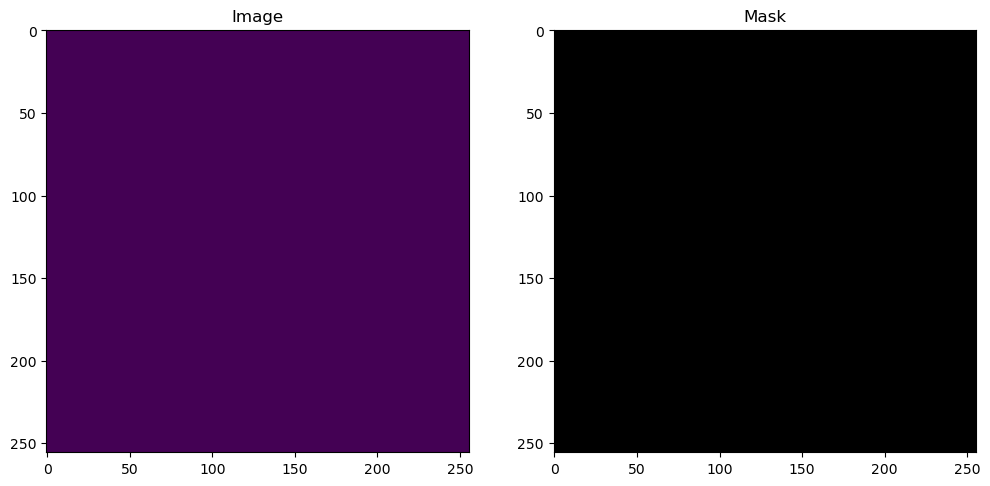

Now preparing image and masks number:  0
I am useless
Now preparing image and masks number:  1
I am useless
Now preparing image and masks number:  2
I am useless
Now preparing image and masks number:  3
I am useless
Now preparing image and masks number:  4
I am useless
Now preparing image and masks number:  5
I am useless
Now preparing image and masks number:  6
I am useless
Now preparing image and masks number:  7
I am useless
Now preparing image and masks number:  8
I am useless
Now preparing image and masks number:  9
I am useless
Now preparing image and masks number:  10
I am useless
Now preparing image and masks number:  11
I am useless
Now preparing image and masks number:  12
I am useless
Now preparing image and masks number:  13
I am useless
Now preparing image and masks number:  14
I am useless
Now preparing image and masks number:  15
I am useless
Now preparing image and masks number:  16
I am useless
Now preparing image and masks number:  17
I am useless
Now preparing image 

I am useless
Now preparing image and masks number:  172
I am useless
Now preparing image and masks number:  173
I am useless
Now preparing image and masks number:  174
I am useless
Now preparing image and masks number:  175
I am useless
Now preparing image and masks number:  176
I am useless
Now preparing image and masks number:  177
I am useless
Now preparing image and masks number:  178
I am useless
Now preparing image and masks number:  179
I am useless
Now preparing image and masks number:  180
I am useless
Now preparing image and masks number:  181
I am useless
Now preparing image and masks number:  182
I am useless
Now preparing image and masks number:  183
I am useless
Now preparing image and masks number:  184
I am useless
Now preparing image and masks number:  185
I am useless
Now preparing image and masks number:  186
I am useless
Now preparing image and masks number:  187
I am useless
Now preparing image and masks number:  188
I am useless
Now preparing image and masks numbe

I am useless
Now preparing image and masks number:  336
I am useless
Now preparing image and masks number:  337
I am useless
Now preparing image and masks number:  338
I am useless
Now preparing image and masks number:  339
I am useless
Now preparing image and masks number:  340
I am useless
Now preparing image and masks number:  341
I am useless
Now preparing image and masks number:  342
I am useless
Now preparing image and masks number:  343
I am useless
Now preparing image and masks number:  344
Saving
Now preparing image and masks number:  345
I am useless
Now preparing image and masks number:  346
I am useless
Now preparing image and masks number:  347
I am useless
Now preparing image and masks number:  348
I am useless
Now preparing image and masks number:  349
I am useless
Now preparing image and masks number:  350
I am useless
Now preparing image and masks number:  351
I am useless
Now preparing image and masks number:  352
I am useless
Now preparing image and masks number:  35

I am useless
Now preparing image and masks number:  494
I am useless
Now preparing image and masks number:  495
I am useless
Now preparing image and masks number:  496
I am useless
Now preparing image and masks number:  497
I am useless
Now preparing image and masks number:  498
I am useless
Now preparing image and masks number:  499
I am useless
Now preparing image and masks number:  500
I am useless
Now preparing image and masks number:  501
I am useless
Now preparing image and masks number:  502
I am useless
Now preparing image and masks number:  503
I am useless
Now preparing image and masks number:  504
I am useless
Now preparing image and masks number:  505
I am useless
Now preparing image and masks number:  506
I am useless
Now preparing image and masks number:  507
I am useless
Now preparing image and masks number:  508
I am useless
Now preparing image and masks number:  509
I am useless
Now preparing image and masks number:  510
I am useless
Now preparing image and masks numbe

I am useless
Now preparing image and masks number:  660
I am useless
Now preparing image and masks number:  661
I am useless
Now preparing image and masks number:  662
I am useless
Now preparing image and masks number:  663
I am useless
Now preparing image and masks number:  664
I am useless
Now preparing image and masks number:  665
I am useless
Now preparing image and masks number:  666
I am useless
Now preparing image and masks number:  667
I am useless
Now preparing image and masks number:  668
I am useless
Now preparing image and masks number:  669
I am useless
Now preparing image and masks number:  670
I am useless
Now preparing image and masks number:  671
I am useless
Now preparing image and masks number:  672
I am useless
Now preparing image and masks number:  673
I am useless
Now preparing image and masks number:  674
I am useless
Now preparing image and masks number:  675
I am useless
Now preparing image and masks number:  676
I am useless
Now preparing image and masks numbe

...

I am useless
Now preparing image and masks number:  21509
I am useless
Now preparing image and masks number:  21510
I am useless
Now preparing image and masks number:  21511
I am useless
Now preparing image and masks number:  21512
I am useless
Now preparing image and masks number:  21513
I am useless
Now preparing image and masks number:  21514
I am useless
Now preparing image and masks number:  21515
I am useless
Now preparing image and masks number:  21516
I am useless
Now preparing image and masks number:  21517
I am useless
Now preparing image and masks number:  21518
I am useless
Now preparing image and masks number:  21519
I am useless
Now preparing image and masks number:  21520
I am useless
Now preparing image and masks number:  21521
I am useless
Now preparing image and masks number:  21522
I am useless
Now preparing image and masks number:  21523
I am useless
Now preparing image and masks number:  21524
I am useless
Now preparing image and masks number:  21525
I am useless
N

I am useless
Now preparing image and masks number:  21687
I am useless
Now preparing image and masks number:  21688
I am useless
Now preparing image and masks number:  21689
I am useless
Now preparing image and masks number:  21690
I am useless
Now preparing image and masks number:  21691
I am useless
Now preparing image and masks number:  21692
I am useless
Now preparing image and masks number:  21693
I am useless
Now preparing image and masks number:  21694
I am useless
Now preparing image and masks number:  21695
I am useless
Now preparing image and masks number:  21696
I am useless
Now preparing image and masks number:  21697
I am useless
Now preparing image and masks number:  21698
I am useless
Now preparing image and masks number:  21699
I am useless
Now preparing image and masks number:  21700
I am useless
Now preparing image and masks number:  21701
I am useless
Now preparing image and masks number:  21702
I am useless
Now preparing image and masks number:  21703
I am useless
N

Now preparing image and masks number:  21862
I am useless
Now preparing image and masks number:  21863
I am useless
Now preparing image and masks number:  21864
I am useless
Now preparing image and masks number:  21865
I am useless
Now preparing image and masks number:  21866
I am useless
Now preparing image and masks number:  21867
Saving
Now preparing image and masks number:  21868
I am useless
Now preparing image and masks number:  21869
I am useless
Now preparing image and masks number:  21870
I am useless
Now preparing image and masks number:  21871
I am useless
Now preparing image and masks number:  21872
I am useless
Now preparing image and masks number:  21873
I am useless
Now preparing image and masks number:  21874
I am useless
Now preparing image and masks number:  21875
I am useless
Now preparing image and masks number:  21876
I am useless
Now preparing image and masks number:  21877
I am useless
Now preparing image and masks number:  21878
I am useless
Now preparing image 

Copying files: 474 files [00:00, 2118.03 files/s]


'\nYour current directory structure:\nData/\n    train/\n        images/\n            img1, img2, ...\n        masks/\n            msk1, msk2, ....\n    val/\n        images/\n            img1, img2, ...\n        masks/\n            msk1, msk2, ....\n        \nCopy the folders around to the following structure... \n\n\nData/\n    train_images/\n                train/\n                    img1, img2, img3, ......\n    \n    train_masks/\n                train/\n                    msk1, msk, msk3, ......\n                    \n    val_images/\n                val/\n                    img1, img2, img3, ......                \n\n    val_masks/\n                val/\n                    msk1, msk, msk3, ......\n      \n                    \n'

In [56]:
#####################################################
# Generate patches
#####################################################

img_format = 'tiff'
region = 'Siberia'
out_format = 'tiff'
patch_size = 256
step = 128

#pref_instr = 'LT05'
pref_instr = 'LC08'
#pref_instr = 'LE07'

print(f'\nInstrument {pref_instr} will be processed...')

########################################
# Create directories
#########################################

root_directory = f'/data/rrs/seaice/aux_data/s1/tundra_lakes/{region}'
patch_folder_name = f'{pref_instr}_{patch_size}_patches_rgb'

# Directories with input data
img_dir = f'{root_directory}/{img_format}_rgb'
mask_dir = f'{root_directory}/masks_{img_format}'

img_patch_dir = f'{root_directory}/{patch_folder_name}/images/'
os.makedirs(img_patch_dir, exist_ok=True)

mask_patch_dir = f'{root_directory}/{patch_folder_name}/masks/'
os.makedirs(mask_patch_dir, exist_ok=True)

# Images with useful info
useful_info_dir = f'{root_directory}/{patch_folder_name}/images_with_useful_info/'
os.makedirs(useful_info_dir, exist_ok=True)

useful_info_img_dir = f'{root_directory}/{patch_folder_name}/images_with_useful_info/images/'
os.makedirs(useful_info_img_dir, exist_ok=True)

useful_info_mask_dir = f'{root_directory}/{patch_folder_name}/images_with_useful_info/masks/'
os.makedirs(useful_info_mask_dir, exist_ok=True)

for path, subdirs, files in os.walk(img_dir):
    dirname = path.split(os.path.sep)[-1]
    images = glob.glob(f'''{path}/*{pref_instr}*.tiff''')
    
    for i, image_name in enumerate(images): 
        # Process image only if there is a corresponding mask
        proc_f = False
        tmp_fname = os.path.basename(image_name).split('.')[0]
        
        if len(glob.glob(f'''{mask_dir}/{tmp_fname}*''')) > 0:
            proc_f = True
        else:
            proc_f = False
                               
        if image_name.endswith(f'.{img_format}') and proc_f==True:
            print(image_name)
            image = gdal.Open(image_name).ReadAsArray()
            SIZE_X = (image.shape[2]//patch_size)*patch_size #Nearest size divisible by our patch size
            SIZE_Y = (image.shape[1]//patch_size)*patch_size #Nearest size divisible by our patch size
            image = image[:,0:SIZE_Y,0:SIZE_X]
            
            # Apply anisotropic diffusion smoothing (FOR SAR ONLY)
            #im_hv = anisodiff(image[0,:,:], niter=10, kappa=60)
            #im_hh = anisodiff(image[1,:,:], niter=10, kappa=60)
            #im_ia = image[2,:,:]
            #image = np.stack([im_hv, im_hh, im_ia])
            
            image = np.moveaxis(image, 0, -1)
   
            #Extract patches from each image
            #print("Now patchifying image:", image_name)
            patches_img = patchify(image, (patch_size, patch_size, 3), step=step)
    
            for i in range(patches_img.shape[0]):
                for j in range(patches_img.shape[1]):
                    
                    single_patch_img = patches_img[i,j,:,:]
                    #single_patch_img = (single_patch_img.astype('float32')) / 255. #We will preprocess using one of the backbones
                    single_patch_img = single_patch_img[0] #Drop the extra unecessary dimension that patchify adds.                               
                    
                    #out_patch_name = f'{img_patch_dir}/{image_name}patch_{+str(i)+str(j)}.tiff'
                    tmp_fname = os.path.basename(image_name).split('.')[0]
                    out_patch_name = f'{img_patch_dir}/{tmp_fname}_patch_{str(i)}_{str(j)}.tiff'
                    imageio.imwrite(out_patch_name, single_patch_img)
                    
                    #image_dataset.append(single_patch_img)
            
# Now do the same as above for masks
print('\n')

for path, subdirs, files in os.walk(mask_dir):
    #print(path)  
    dirname = path.split(os.path.sep)[-1]
    #masks = os.listdir(path)  #List of all image names in this subdirectory
    masks = glob.glob(f'''{path}/*{pref_instr}*.tiff''')
    
    for i, mask_name in enumerate(masks):  
        if mask_name.endswith(f'.{out_format}'):           
            mask = gdal.Open(f'{mask_name}').ReadAsArray()
            SIZE_X = (mask.shape[1]//patch_size)*patch_size #Nearest size divisible by our patch size
            SIZE_Y = (mask.shape[0]//patch_size)*patch_size #Nearest size divisible by our patch size
            mask = Image.fromarray(mask)
            mask = mask.crop((0 ,0, SIZE_X, SIZE_Y))  #Crop from top left corner
            #mask = mask.resize((SIZE_X, SIZE_Y))  #Try not to resize for semantic segmentation
            mask = np.array(mask)             
   
            #Extract patches from each image
            print("Now patchifying mask:", mask_name)
            patches_mask = patchify(mask, (patch_size, patch_size), step=step)  #Step=256 for 256 patches means no overlap
    
            for i in range(patches_mask.shape[0]):
                for j in range(patches_mask.shape[1]):
                    single_patch_mask = patches_mask[i,j,:,:]
                    #single_patch_img = (single_patch_img.astype('float32')) / 255. #No need to scale masks, but you can do it if you want
                    #single_patch_mask = single_patch_mask[0] #Drop the extra unecessary dimension that patchify adds.   
                    tmp_fname = os.path.basename(mask_name).split('.')[0]
                    out_patch_name = f'{mask_patch_dir}/{tmp_fname}_patch_{str(i)}_{str(j)}.tiff'
                    imageio.imwrite(out_patch_name, single_patch_mask)


# Plot random mask
mask_files = glob.glob(f'{mask_patch_dir}/*.tiff')
m_filename = mask_files[random.randint(0, len(mask_files))]
mask_file = gdal.Open(m_filename).ReadAsArray()
img_file = glob.glob(f'''{img_patch_dir}/{os.path.basename(m_filename)[:-5]}*''')[0]
img_file = gdal.Open(img_file).ReadAsArray()[:,:]

plt.figure(figsize=(12, 8))
plt.subplot(121)
plt.imshow(img_file[0,:,:])
plt.title('Image')
plt.subplot(122)
plt.imshow(mask_file, cmap='gray')
plt.title('Mask')
plt.show()


###########################################################################
# Copy images and masks with real information to a new folder.
# real information = if mask has decent amount of labels other than 0. 

useless=0  #Useless image counter

img_list = glob.glob(f'{img_patch_dir}/*.tiff')           
msk_list = glob.glob(f'{mask_patch_dir}/*.tiff')           

for i in range(len(img_list)):   #Using t1_list as all lists are of same size
    img_name = img_list[i]
    mask_name = msk_list[i]
    print("Now preparing image and masks number: ", i)
      
    temp_image = gdal.Open(img_name).ReadAsArray()
    temp_image = np.moveaxis(temp_image, 0, -1)
    temp_mask = gdal.Open(mask_name).ReadAsArray()
    
    #temp_mask=temp_mask.astype(np.uint8)
    
    val, counts = np.unique(temp_mask, return_counts=True)
    
    if (1 - (counts[0]/counts.sum())) > 0.05:  #At least 5% useful area with labels that are not 0
        print("Saving")       
        imageio.imwrite(f'{useful_info_img_dir}/{os.path.basename(img_name)}', temp_image)
        imageio.imwrite(f'{useful_info_mask_dir}/{os.path.basename(mask_name)}', temp_mask)      
        del temp_image
        del temp_mask
    else:
        print("I am useless")   
        useless += 1

print("Total useful images are: ", len(img_list)-useless)  #20,075
print("Total useless images are: ", useless) #21,571


###############################################################
#Now split the data into training, validation and testing. 

"""
Code for splitting folder into train, test, and val.
Once the new folders are created rename them and arrange in the format below to be used
for semantic segmentation using data generators. 

pip install split-folders
"""
import splitfolders  # or import split_folders

input_folder = useful_info_dir
os.makedirs(input_folder, exist_ok=True)
output_folder = f'{root_directory}/{patch_folder_name}/data_for_training_and_testing/'
os.makedirs(output_folder, exist_ok=True)

# Split with a ratio.
# To only split into training and validation set, set a tuple to `ratio`, i.e, `(.8, .2)`.
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.75, .25), group_prefix=None) # default values
########################################

#Now manually move folders around to bring them to the following structure.
"""
Your current directory structure:
Data/
    train/
        images/
            img1, img2, ...
        masks/
            msk1, msk2, ....
    val/
        images/
            img1, img2, ...
        masks/
            msk1, msk2, ....
        
Copy the folders around to the following structure... 


Data/
    train_images/
                train/
                    img1, img2, img3, ......
    
    train_masks/
                train/
                    msk1, msk, msk3, ......
                    
    val_images/
                val/
                    img1, img2, img3, ......                

    val_masks/
                val/
                    msk1, msk, msk3, ......
      
                    
"""


In [41]:
np.nanmax(gdal.Open('/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/LT05_256_patches_rgb/images_with_useful_info/images/LT05_L1TP_164011_19980721_20201008_02_T1_rgb_patch_18_40.tiff').ReadAsArray())

0.69069576